# Data Exploration

The dataset is the "1 million Sudoku games" from Kaggle: https://www.kaggle.com/datasets/bryanpark/sudoku. Let's explore it in more detail

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load("../data/sudoku.npz")
train_x = data["train_x"]
train_x.shape

(990000, 81)

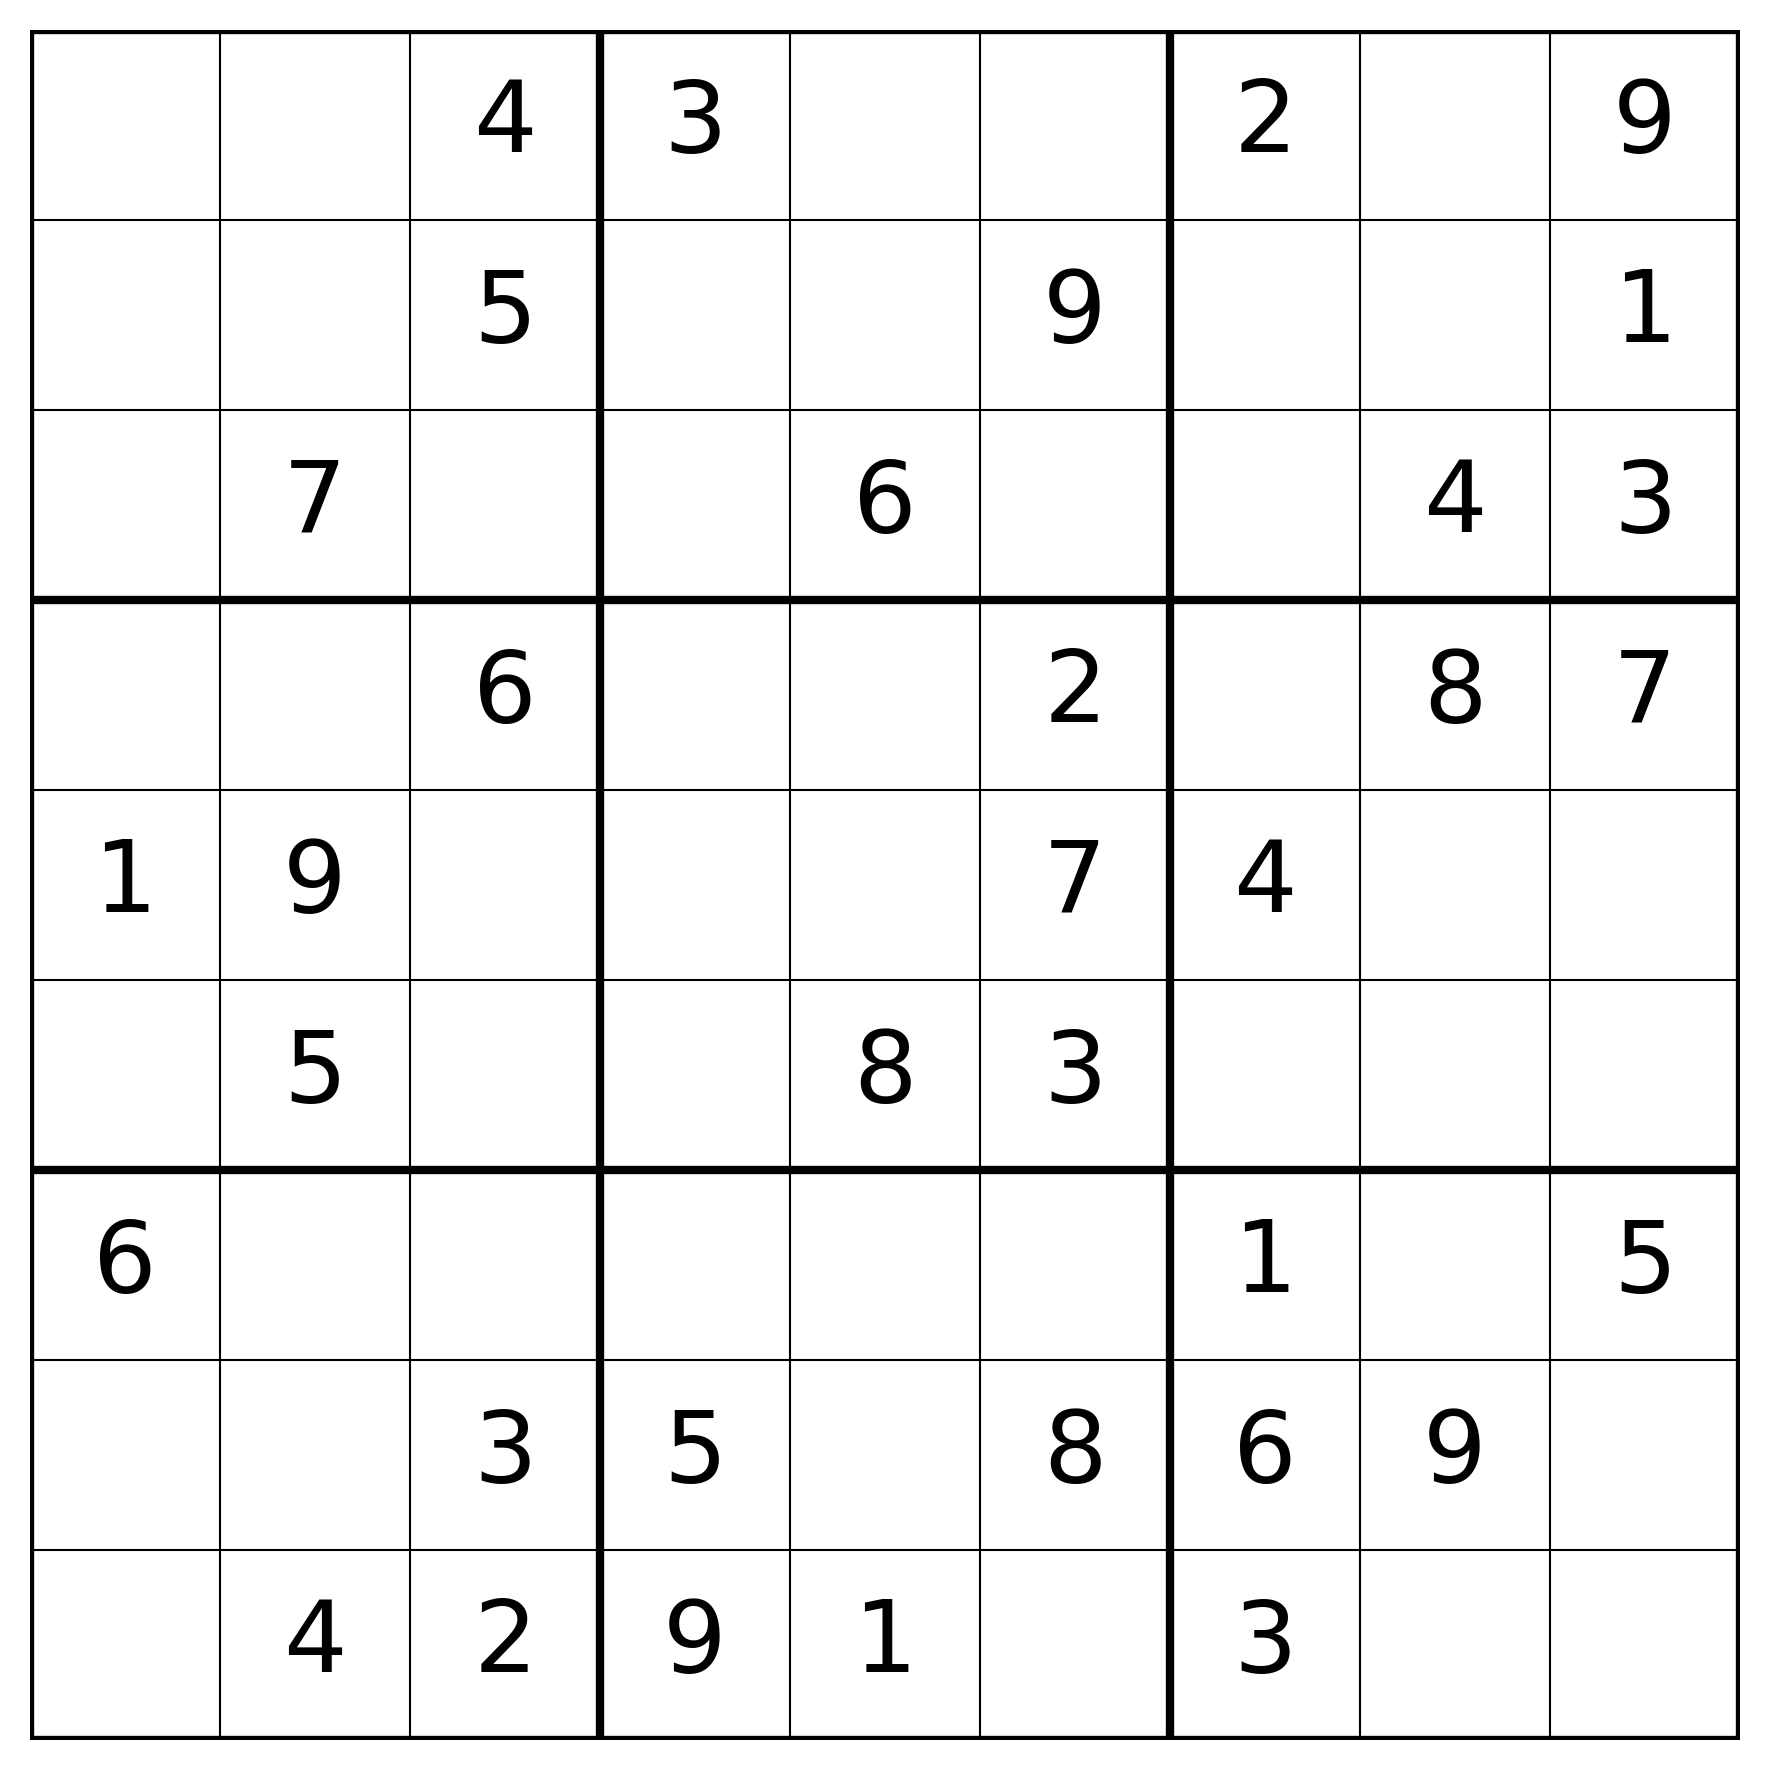

In [25]:
sample_puzzle = train_x[0].reshape(9, 9)

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Draw the grid
for i in range(10):
    linewidth = 2 if i % 3 == 0 else 0.5
    ax.plot([0, 9], [i, i], 'k-', linewidth=linewidth)
    ax.plot([i, i], [0, 9], 'k-', linewidth=linewidth)

# Fill in the numbers
for i in range(9):
    for j in range(9):
        if sample_puzzle[i, j] != 0:
            ax.text(j + 0.5, 8.5 - i, str(sample_puzzle[i, j]), 
                   ha='center', va='center', fontsize=24, fontweight='normal')

ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.set_aspect('equal')
ax.axis('off')
plt.savefig("../img/sample_puzzle.png")
plt.tight_layout()
plt.show()

## Hint Counts

In [3]:
hint_counts = 81 - (train_x == 0).mean(axis=1) * 81
hint_counts.shape

(990000,)

We have a fairly narrow distibution of hints ranging from 29 to 37 with 34 being most common.

29: 28
30: 522
31: 7,672
32: 60,515
33: 261,252
34: 450,482
35: 196,945
36: 12,527
37: 57


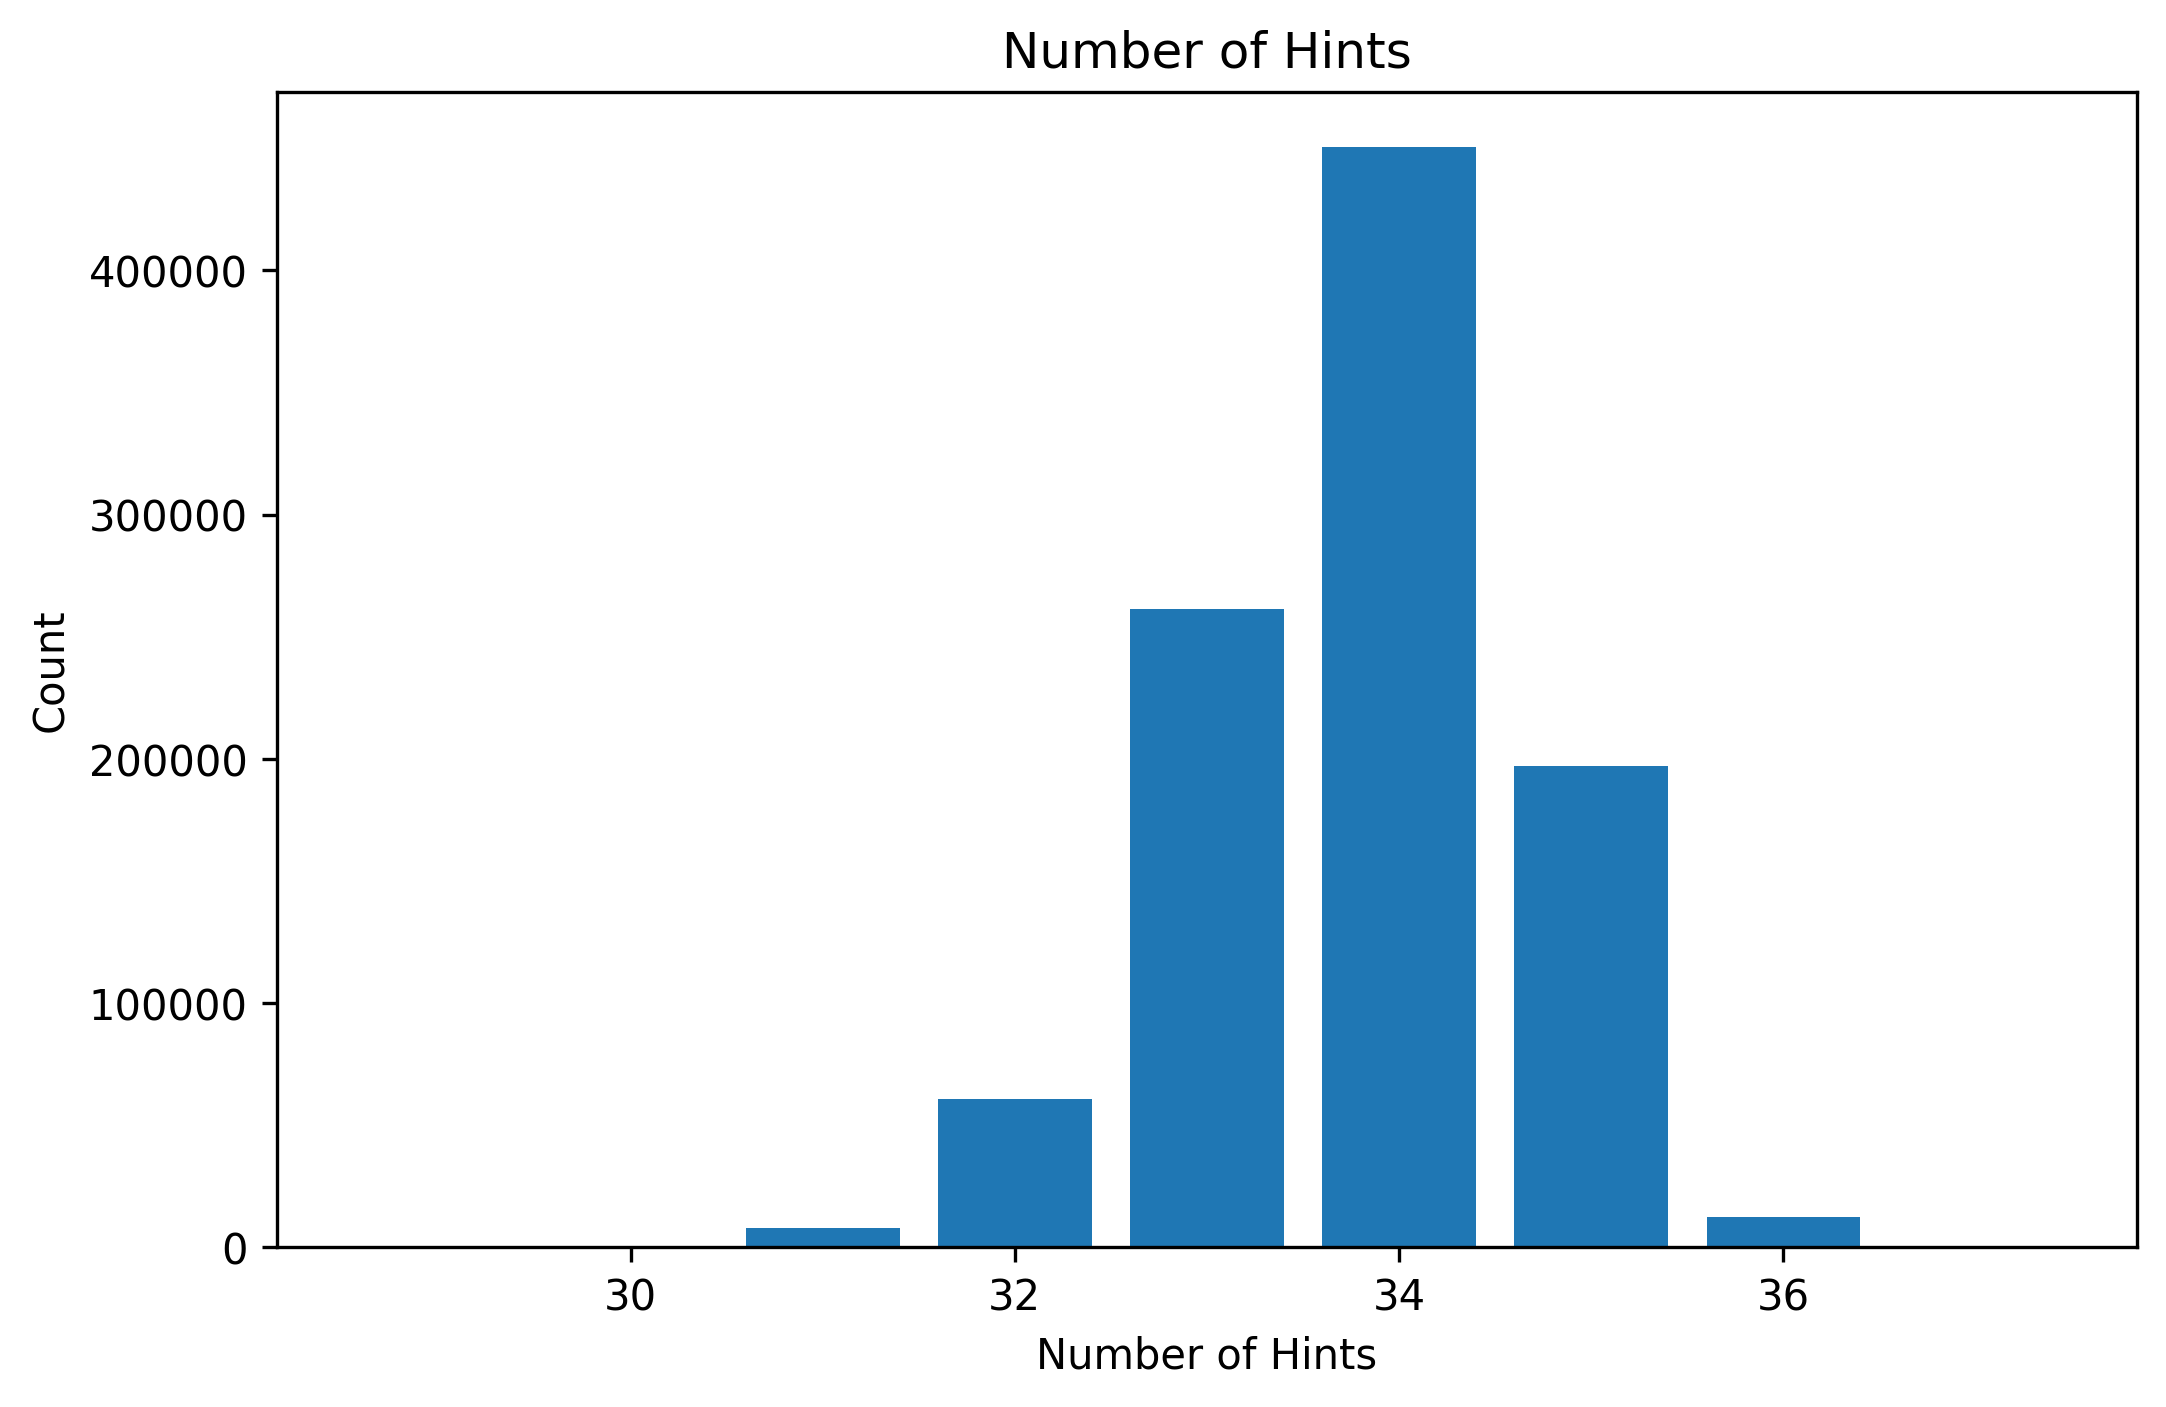

In [6]:
unique, counts = np.unique(hint_counts, return_counts=True)
for u, c in zip(unique, counts):
    print(f"{u:.0f}: {c:,}")
plt.figure(dpi=300, figsize=(8, 5))
plt.bar(unique, counts)
plt.title("Number of Hints")
plt.xlabel('Number of Hints')
plt.ylabel('Count')
plt.savefig("../img/hint_numbers.png")
plt.show()

# Hint Distribution

The hints are fairly well distributed but with a clear pattern.

In [8]:
hint_data = (train_x == 0).mean(axis=0).reshape(9, 9)

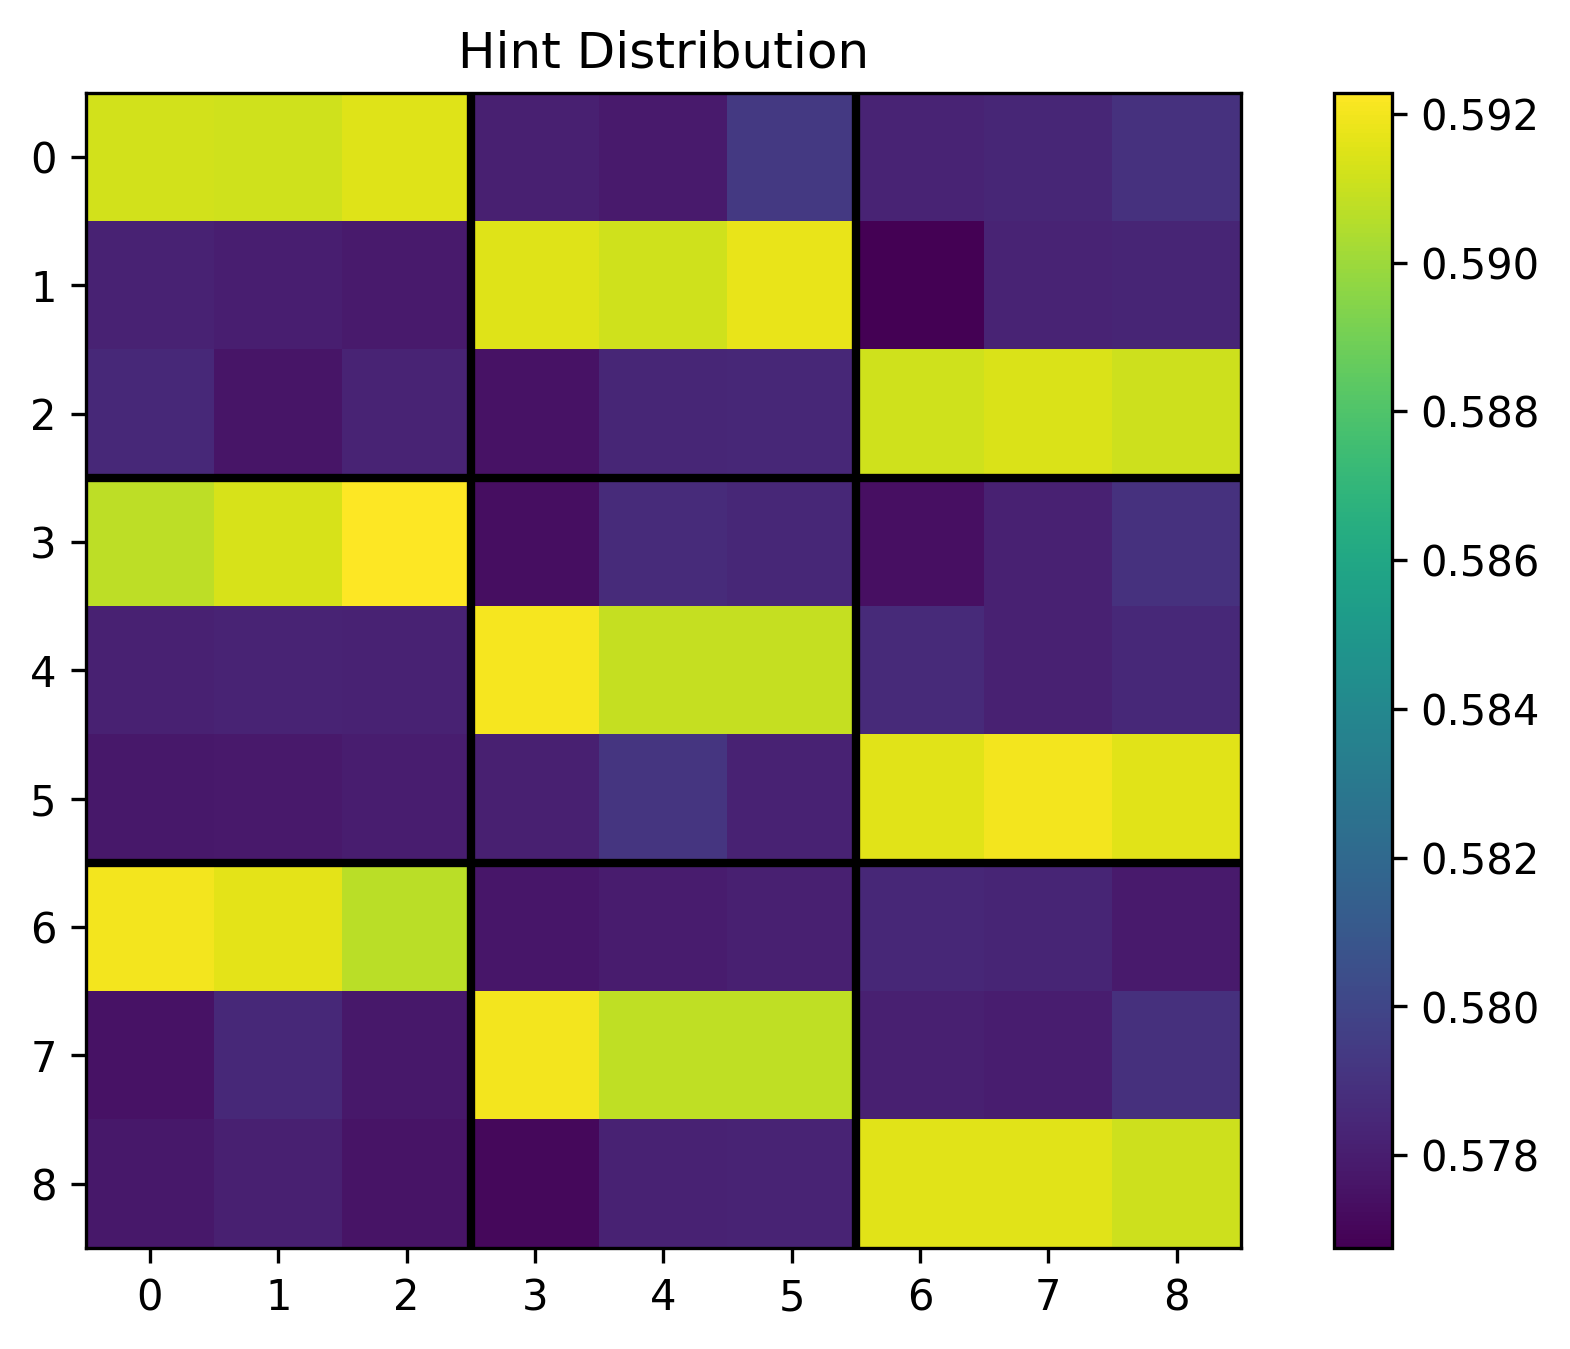

In [9]:
heatmap_data = (train_x == 0).mean(axis=0).reshape(9, 9)
plt.figure(dpi=300, figsize=(8, 5))
plt.imshow(hint_data, cmap='viridis')
plt.colorbar()
for i in [2.5, 5.5]:
    plt.axhline(i, color='black', linewidth=2)
    plt.axvline(i, color='black', linewidth=2)
plt.title('Hint Distribution')
plt.savefig("../img/hint_distribution.png")
plt.show()